In [2]:
# If you need to (re)install numpy, run the next line and then restart the kernel before re-running cells:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2-4*x+5

In [4]:
xs = np.arange(-10, 10, 0.1)
ys = f(xs)  
ys

array([345.  , 338.63, 332.32, 326.07, 319.88, 313.75, 307.68, 301.67,
       295.72, 289.83, 284.  , 278.23, 272.52, 266.87, 261.28, 255.75,
       250.28, 244.87, 239.52, 234.23, 229.  , 223.83, 218.72, 213.67,
       208.68, 203.75, 198.88, 194.07, 189.32, 184.63, 180.  , 175.43,
       170.92, 166.47, 162.08, 157.75, 153.48, 149.27, 145.12, 141.03,
       137.  , 133.03, 129.12, 125.27, 121.48, 117.75, 114.08, 110.47,
       106.92, 103.43, 100.  ,  96.63,  93.32,  90.07,  86.88,  83.75,
        80.68,  77.67,  74.72,  71.83,  69.  ,  66.23,  63.52,  60.87,
        58.28,  55.75,  53.28,  50.87,  48.52,  46.23,  44.  ,  41.83,
        39.72,  37.67,  35.68,  33.75,  31.88,  30.07,  28.32,  26.63,
        25.  ,  23.43,  21.92,  20.47,  19.08,  17.75,  16.48,  15.27,
        14.12,  13.03,  12.  ,  11.03,  10.12,   9.27,   8.48,   7.75,
         7.08,   6.47,   5.92,   5.43,   5.  ,   4.63,   4.32,   4.07,
         3.88,   3.75,   3.68,   3.67,   3.72,   3.83,   4.  ,   4.23,
      

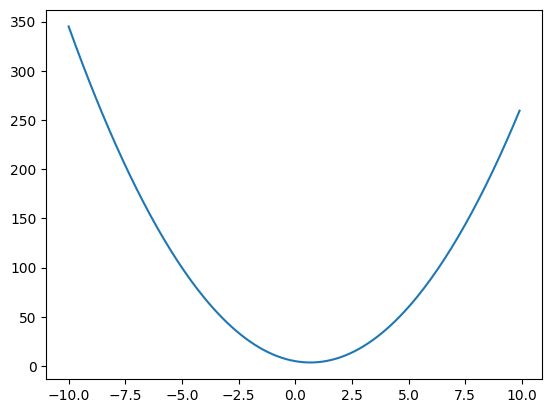

In [5]:
plt.plot(xs, ys)

In [6]:
class Value:
    def __init__(self,data, _children=(),_op ='', lable=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = lable
        
    def __repr__(self):
        return f'Value({self.data})'
    
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
    





    
    








    
a = Value(3.0, lable='a')
b = Value(4.0, lable='b')
print(a)
print(b)
print(a + b,)
c= Value(5.0, lable='c')
d = a*b + c
d.label = 'd'
print(d)

d._prev

Value(3.0)
Value(4.0)
Value(7.0)
Value(17.0)


{Value(12.0), Value(5.0)}

In [21]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ data %.4f | grad %.4f }" % (0.0,
                                                                 n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

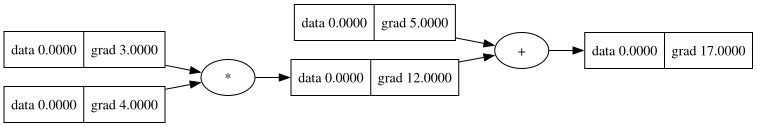

In [22]:
draw_dot(d)